In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.metrics import accuracy_score
from utils import utils_ml 

from catboost import CatBoostClassifier, CatBoostRegressor
from sklearn.feature_selection import VarianceThreshold
import glob 

In [2]:
# Automatically find the matching file
input_files = glob.glob('training_features*.npy')
if not input_files:
    raise FileNotFoundError("No features_filtered*.npy file found in current directory")
input_path = input_files[0]

# Load memory-mapped array
print(f"Loading features from {input_path}")
X_arr = np.load(input_path, mmap_mode='r').astype(np.float32)[::100]

# Class mapping dictionary
class_to_poles = {
    0: [0, 0, 0],  # 1 pole on [bt]
    1: [1, 0, 0],  # 1 pole on [bb]
    2: [0, 1, 0],  # 1 pole on [tb]
    3: [0, 0, 1],  # 1 pole on [bt] and 1 pole on [bb]
    4: [2, 0, 0],  # 1 pole on [bb] and 1 pole on [tb]
    5: [0, 2, 0],  # 1 pole on each of [bt], [bb], and [tb]
    6: [0, 0, 2],  # 2 poles on [bb] and 1 pole on [tb]
    7: [1, 1, 0],  # 1 pole on [bb] and 2 poles on [tb]
    8: [1, 0, 1],
    9: [0, 1, 1],
    10: [3, 0, 0],
    11: [0, 3, 0],
    12: [0, 0, 3],
    13: [2, 1, 0],
    14: [2, 0, 1],
    15: [1, 2, 0],
    16: [0, 2, 1],
    17: [1, 0, 2],
    18: [0, 1, 2],
    19: [1, 1, 1],
    20: [4, 0, 0],
    21: [0, 4, 0],
    22: [0, 0, 4],
    23: [3, 1, 0],
    24: [3, 0, 1],
    25: [1, 3, 0],
    26: [0, 3, 1],
    27: [1, 0, 3],
    28: [0, 1, 3],
    29: [2, 2, 0],
    30: [2, 0, 2],
    31: [0, 2, 2],
    32: [2, 1, 1],
    33: [1, 2, 1],
    34: [1, 1, 2],
}


# File paths
file_prefix = "rawFeatures/P"
file_suffix = "_intensity.pkl"
num_files = 35

# Load labels
print("Loading labels...")
y_arr_classification = np.array([
    np.tile(i, 10000) 
    for i in np.arange(num_files)
]).flatten()[::100]

def convert_labels(old_labels, class_to_poles):
    """
    Convert class labels to pole representation.
    
    Parameters:
        old_labels (np.ndarray): Array of class labels.
        class_to_poles (dict): Mapping from class labels to pole representations.
        
    Returns:
        np.ndarray: A 2D array with pole representations.
    """
    # Initialize a new array with shape (length of old labels, 3)
    new_labels = np.zeros((len(old_labels), 3), dtype=int)
    
    # Populate the new label array based on the mapping
    for i, label in enumerate(old_labels):
        new_labels[i] = class_to_poles[label]
    
    return new_labels

y_arr_regression = convert_labels(y_arr_classification, class_to_poles) * 1.0

class_to_poles_arr = np.array([class_to_poles[i] for i in range(num_files)])
y_bt = class_to_poles_arr[y_arr_classification][:, 0]
y_bb = class_to_poles_arr[y_arr_classification][:, 1]
y_tb = class_to_poles_arr[y_arr_classification][:, 2]

Loading features from training_features_128_T11NoBG.npy
Loading labels...


In [3]:
from sklearn.base import clone
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.multioutput import ClassifierChain
import numpy as np
from sklearn.model_selection import train_test_split
import os 
import joblib

class WrappedCatBoost(BaseEstimator, ClassifierMixin):
    def __init__(self, **params):
        self.params = params
        self.model = CatBoostClassifier(**self.params, verbose=100)

    def fit(self, X, y, eval_set=None):
        if eval_set is not None:
            self.model.fit(X, y, use_best_model=True, early_stopping_rounds=10, eval_set=eval_set)
        else:
            self.model.fit(X, y)
        self.classes_ = np.unique(y)
        return self

    def predict(self, X):
        preds = self.model.predict(X)
        return preds.reshape(-1)

    def predict_proba(self, X):
        return self.model.predict_proba(X)
    
    def save_model(self, filepath):
        """Save the CatBoost model to file."""
        self.model.save_model(filepath)
    
    def load_model(self, filepath):
        """Load the CatBoost model from file."""
        self.model.load_model(filepath)
        return self


class ClassifierChain(ClassifierChain):
    def fit(self, X, Y, eval_set=None, **fit_params):
        """Custom fit to support eval_set for each wrapped estimator."""
        from sklearn.utils import check_X_y
        X = np.asarray(X)
        Y = np.asarray(Y)

        self.order_ = self.order if self.order != 'random' else np.random.permutation(Y.shape[1])
        self.estimators_ = []

        for chain_idx, label_idx in enumerate(self.order_):
            y = Y[:, label_idx]
            if chain_idx > 0:
                X_extended = np.hstack((X, Y[:, self.order_[:chain_idx]]))
            else:
                X_extended = X

            estimator = clone(self.base_estimator)

            if eval_set is not None:
                X_val, Y_val = eval_set
                y_val = Y_val[:, label_idx]
                if chain_idx > 0:
                    X_val_extended = np.hstack((X_val, Y_val[:, self.order_[:chain_idx]]))
                else:
                    X_val_extended = X_val
                estimator.fit(X_extended, y, eval_set=(X_val_extended, y_val))
            else:
                estimator.fit(X_extended, y)

            self.estimators_.append(estimator)

        return self

    def save_chain(self, base_filepath):
        """Save the entire classifier chain."""
        # Save the chain structure using joblib
        chain_data = {
            'order_': self.order_,
            'order': self.order,
            'base_estimator': self.base_estimator
        }
        joblib.dump(chain_data, f"{base_filepath}_chain.pkl")
        
        # Save each individual estimator
        os.makedirs(f"{base_filepath}_models", exist_ok=True)
        for idx, estimator in enumerate(self.estimators_):
            if hasattr(estimator, 'save_model'):
                estimator.save_model(f"{base_filepath}_models/model_{idx}.cbm")
            else:
                joblib.dump(estimator, f"{base_filepath}_models/model_{idx}.pkl")
    
    def load_chain(self, base_filepath, classes=None):
        """Load the entire classifier chain."""
        # Load chain structure
        chain_data = joblib.load(f"{base_filepath}_chain.pkl")
        self.order_ = chain_data['order_']
        self.order = chain_data['order']
        self.base_estimator = chain_data['base_estimator']
        
        # Load individual estimators
        self.estimators_ = []
        for idx in range(len(self.order_)):
            estimator = clone(self.base_estimator)
            cbm_path = f"{base_filepath}_models/model_{idx}.cbm"
            pkl_path = f"{base_filepath}_models/model_{idx}.pkl"
            
            if os.path.exists(cbm_path) and hasattr(estimator, 'load_model'):
                estimator.load_model(cbm_path)
                # Set classes if provided
                if classes is not None:
                    estimator.classes_ = classes
            elif os.path.exists(pkl_path):
                estimator = joblib.load(pkl_path)
            
            self.estimators_.append(estimator)
        
        return self

# c3r_acc = []
# for i in range(3):

#     base_clf = WrappedCatBoost(loss_function='MultiClass', random_seed=42)

#     new_chain = ClassifierChain(base_estimator=base_clf, order=[0, 1, 2])
#     new_chain.load_chain(f"models/catboost_model_c3r_fold{i}",classes=np.unique(y_arr_regression))

#     # Verify loaded model works
#     y_pred = new_chain.predict(X_arr)
#     acc = accuracy_score(utils_ml.reconvert_labels(y_pred,class_to_poles),utils_ml.reconvert_labels(y_arr_regression,class_to_poles))
#     c3r_acc.append(acc)


# Prepare split
# X_train, X_test, y_train, y_test = train_test_split(X_arr, y_arr_regression, test_size=0.2, random_state=42)

# # Define base model
# base_clf = WrappedCatBoost(loss_function='MultiClass', iterations=1000, random_seed=42)

# # Use custom classifier chain with eval_set support
# chain = EvalClassifierChain(base_estimator=base_clf, order=[0, 1, 2])

# # Fit with validation set
# chain.fit(X_train[::100], y_train[::100], eval_set=(X_test, y_test))

# # Predict
# predictions = chain.predict(X_test)

# chain.save_chain("my_classifier_chain")




# accuracy_score(utils_ml.reconvert_labels(predictions,class_to_poles),utils_ml.reconvert_labels(y_test,class_to_poles))

In [4]:
class Ensemble(object):
    
    def __init__(self, esize=10, iterations=1000, seed=42):
        
        
        self.seed = seed
        self.esize=esize
        self.iterations=iterations
        self.ensemble = []
        for e in range(self.esize):
            model = CatBoostClassifier(iterations=self.iterations,
                           loss_function='MultiClass',
                           verbose=100,
                           bootstrap_type='No',
                           posterior_sampling=True,
                           random_seed=self.seed+e,
                           early_stopping_rounds=10)
            self.ensemble.append(model)
        
    def fit(self, X,y, eval_set = None):
        
        for m in self.ensemble:
            m.fit(X, y, use_best_model=True, early_stopping_rounds=10, eval_set=eval_set)
            print("best iter ", m.get_best_iteration())
            print("best score ", m.get_best_score())
            
    
    def predict(self,x):
        probs = []
        
        for m in self.ensemble:
            prob = m.predict_proba(x)
            probs.append(prob)
        probs = np.stack(probs)
        return probs
    
    def save(self, base_filepath):
        """Save the entire ensemble."""
        # Save ensemble metadata
        metadata = {
            'seed': self.seed,
            'esize': self.esize,
            'iterations': self.iterations,
        }
        joblib.dump(metadata, f"{base_filepath}_metadata.pkl")
        
        # Save each model in the ensemble
        os.makedirs(f"{base_filepath}_models", exist_ok=True)
        for idx, model in enumerate(self.ensemble):
            model.save_model(f"{base_filepath}_models/model_{idx}.cbm")
    
    def load(self, base_filepath):
        """Load the entire ensemble."""
        # Load metadata
        metadata = joblib.load(f"{base_filepath}_metadata.pkl")
        self.seed = metadata['seed']
        self.esize = metadata['esize']
        self.iterations = metadata['iterations']
       
        
        # Load each model
        self.ensemble = []
        for idx in range(self.esize):
            model = CatBoostClassifier(
                iterations=self.iterations,
                loss_function='MultiClass',
                verbose=100,
                bootstrap_type='No',
                posterior_sampling=True,
                random_seed=self.seed+idx,
                early_stopping_rounds=10
            )
            model.load_model(f"{base_filepath}_models/model_{idx}.cbm")
            self.ensemble.append(model)


def kl_divergence(probs1, probs2, epsilon=1e-10):
    return np.sum(probs1 * (np.log(probs1 + epsilon) - np.log(probs2 + epsilon)), axis=1)

def entropy_of_expected(probs, epsilon=1e-10):
    mean_probs = np.mean(probs, axis=0)
    log_probs = -np.log(mean_probs + epsilon)
    return np.sum(mean_probs * log_probs, axis=1)

def expected_entropy(probs, epsilon=1e-10):
    log_probs = -np.log(probs + epsilon)

    return np.mean(np.sum(probs * log_probs, axis=2), axis=0)

def mutual_information(probs, epsilon):
    eoe = entropy_of_expected(probs, epsilon)
    exe = expected_entropy(probs, epsilon)
    return eoe - exe

def ensemble_uncertainties(probs, epsilon=1e-10):
    mean_probs = np.mean(probs, axis=0)
    conf = np.max(mean_probs, axis=1)

    eoe = entropy_of_expected(probs, epsilon)
    exe = expected_entropy(probs, epsilon)
    mutual_info = eoe - exe


    uncertainty = {'confidence': conf,
                   'entropy_of_expected': eoe,        # total_uncertainty !
                   'expected_entropy': exe,           # data_uncertainty !
                   'mutual_information': mutual_info, # Knowledge Uncertainty!
                  }

    return uncertainty

class EnsembleWrapper(BaseEstimator, ClassifierMixin):
    def __init__(self, esize=10, iterations=1000, seed=100):
        self.esize = esize
        self.iterations = iterations
        self.seed = seed

        self.ensemble = Ensemble(
            esize=self.esize,
            iterations=self.iterations,
            seed=self.seed
        )

    def fit(self, X, y, eval_set=None):
        if eval_set is not None:
            X_val, y_val = eval_set
            eval_data = [(X_val, y_val)]
        else:
            eval_data = None
        self.ensemble.fit(X, y, eval_set=eval_data)
        self.classes_ = np.unique(y)
        return self

    def predict(self, X):
        probs = self.ensemble.predict(X)
        mean_probs = np.mean(probs, axis=0)
        return np.argmax(mean_probs, axis=1)

    def predict_proba(self, X):
        return np.mean(self.ensemble.predict(X), axis=0)

    def predict_with_uncertainty(self, X):
        probs = self.ensemble.predict(X)
        return ensemble_uncertainties(probs), probs
    
    def save_model(self, filepath):
        """Save the ensemble wrapper model."""
        # Save wrapper metadata
        wrapper_metadata = {
            'esize': self.esize,
            'iterations': self.iterations,
            'seed': self.seed,
            'classes_': getattr(self, 'classes_', None)
        }
        joblib.dump(wrapper_metadata, f"{filepath}_wrapper.pkl")
        
        # Save the ensemble
        self.ensemble.save(filepath)
    
    def load_model(self, filepath):
        """Load the ensemble wrapper model."""
        # Load wrapper metadata
        wrapper_metadata = joblib.load(f"{filepath}_wrapper.pkl")
        self.esize = wrapper_metadata['esize']
        self.iterations = wrapper_metadata['iterations']
        self.seed = wrapper_metadata['seed']
        if wrapper_metadata['classes_'] is not None:
            self.classes_ = wrapper_metadata['classes_']
        
        # Create and load the ensemble
        self.ensemble = Ensemble(
            esize=self.esize,
            iterations=self.iterations,
            seed=self.seed
        )
        self.ensemble.load(filepath)
        return self


class EvalClassifierChain(ClassifierChain):
    def fit(self, X, Y, eval_set=None, **fit_params):
        """Custom fit to support eval_set for each wrapped estimator."""
        X = np.asarray(X)
        Y = np.asarray(Y)

        self.order_ = self.order if self.order != 'random' else np.random.permutation(Y.shape[1])
        self.estimators_ = []

        for chain_idx, label_idx in enumerate(self.order_):
            y = Y[:, label_idx]
            if chain_idx > 0:
                X_extended = np.hstack((X, Y[:, self.order_[:chain_idx]]))
            else:
                X_extended = X

            estimator = clone(self.base_estimator)

            if eval_set is not None:
                X_val, Y_val = eval_set
                y_val = Y_val[:, label_idx]
                if chain_idx > 0:
                    X_val_extended = np.hstack((X_val, Y_val[:, self.order_[:chain_idx]]))
                else:
                    X_val_extended = X_val
                estimator.fit(X_extended, y, eval_set=(X_val_extended, y_val))
            else:
                estimator.fit(X_extended, y)

            self.estimators_.append(estimator)

        return self

    def save_chain(self, base_filepath):
        """Save the entire classifier chain."""
        # Save the chain structure using joblib
        chain_data = {
            'order_': self.order_,
            'order': self.order,
            'base_estimator': self.base_estimator
        }
        joblib.dump(chain_data, f"{base_filepath}_chain.pkl")
        
        # Save each individual estimator
        os.makedirs(f"{base_filepath}_chain_models", exist_ok=True)
        for idx, estimator in enumerate(self.estimators_):
            if hasattr(estimator, 'save_model'):
                estimator.save_model(f"{base_filepath}_chain_models/estimator_{idx}")
            else:
                joblib.dump(estimator, f"{base_filepath}_chain_models/estimator_{idx}.pkl")

    def load_chain(self, base_filepath, classes=None):
        """Load the entire classifier chain."""
        # Load chain structure
        chain_data = joblib.load(f"{base_filepath}_chain.pkl")
        self.order_ = chain_data['order_']
        self.order = chain_data['order']
        self.base_estimator = chain_data['base_estimator']
        
        # Load individual estimators
        self.estimators_ = []
        for idx in range(len(self.order_)):
            estimator = clone(self.base_estimator)
            
            if hasattr(estimator, 'load_model'):
                estimator.load_model(f"{base_filepath}_chain_models/estimator_{idx}")
                # Set classes if provided
                if classes is not None:
                    estimator.classes_ = classes
            else:
                pkl_path = f"{base_filepath}_chain_models/estimator_{idx}.pkl"
                if os.path.exists(pkl_path):
                    estimator = joblib.load(pkl_path)
            
            self.estimators_.append(estimator)
        
        return self


# Example usage
if __name__ == "__main__":
    # Create sample data
    np.random.seed(42)
   
    
    # Base model is now the ensemble
    base_model = EnsembleWrapper(esize=2, iterations=10, seed=42)  # Small values for quick testing
    
    # Classifier chain with uncertainty-aware base models
    chain = EvalClassifierChain(base_estimator=base_model, order=[0, 1, 2])
    
    # Train (using smaller subset for quick testing)
    chain.fit(X_arr, y_arr_regression, eval_set=(X_arr, y_arr_regression))
    
    # Make predictions
    predictions = chain.predict(X_arr)
    print(f"Original predictions shape: {predictions.shape}")
    
    # Save the entire chain
    chain.save_chain("test")
    
    # Load the chain
    unique_classes = np.array([0, 1, 2])
    new_chain = EvalClassifierChain(base_estimator=base_model, order=[0, 1, 2])
    new_chain.load_chain("test", classes=unique_classes)
    
    # Verify loaded model works
    loaded_predictions = new_chain.predict(X_arr)
    print(f"Loaded predictions shape: {loaded_predictions.shape}")
    print(f"Predictions match: {np.array_equal(predictions, loaded_predictions)}")
    
    # Test uncertainty predictions
    if hasattr(new_chain.estimators_[0], 'predict_with_uncertainty'):
        uncertainty, probs = new_chain.estimators_[0].predict_with_uncertainty(X_arr[:5])
        print(f"Uncertainty keys: {uncertainty.keys()}")
        print(f"Probs shape: {probs.shape}")

Learning rate set to 0.5
0:	learn: 0.7039569	test: 0.7039569	best: 0.7039569 (0)	total: 101ms	remaining: 913ms
9:	learn: 0.1405959	test: 0.1405959	best: 0.1405959 (9)	total: 552ms	remaining: 0us

bestTest = 0.1405958648
bestIteration = 9

best iter  9
best score  {'learn': {'MultiClass': 0.14059586479383684}, 'validation': {'MultiClass': 0.14059586479383684}}
Learning rate set to 0.5
0:	learn: 0.7256991	test: 0.7256991	best: 0.7256991 (0)	total: 49.6ms	remaining: 446ms
9:	learn: 0.1439579	test: 0.1439579	best: 0.1439579 (9)	total: 574ms	remaining: 0us

bestTest = 0.1439578942
bestIteration = 9

best iter  9
best score  {'learn': {'MultiClass': 0.14395789420247654}, 'validation': {'MultiClass': 0.14395789420247654}}
Learning rate set to 0.5
0:	learn: 1.1296379	test: 1.1296379	best: 1.1296379 (0)	total: 47.1ms	remaining: 424ms
9:	learn: 0.4823665	test: 0.4823665	best: 0.4823665 (9)	total: 522ms	remaining: 0us

bestTest = 0.4823664966
bestIteration = 9

best iter  9
best score  {'learn': 

In [5]:
i = 1
base_model = EnsembleWrapper(esize=5, iterations=1000, seed=42)

unique_classes = np.array([0, 1, 2,])
new_chain = EvalClassifierChain(base_estimator=base_model, order=[0, 1, 2])
new_chain.load_chain(f"models/catboost_model_c3ru_fold{i}", classes=np.unique(y_arr_regression))

# Verify loaded model works
y_pred = new_chain.predict(X_arr)
acc = accuracy_score(utils_ml.reconvert_labels(y_pred,class_to_poles),utils_ml.reconvert_labels(y_arr_regression,class_to_poles))


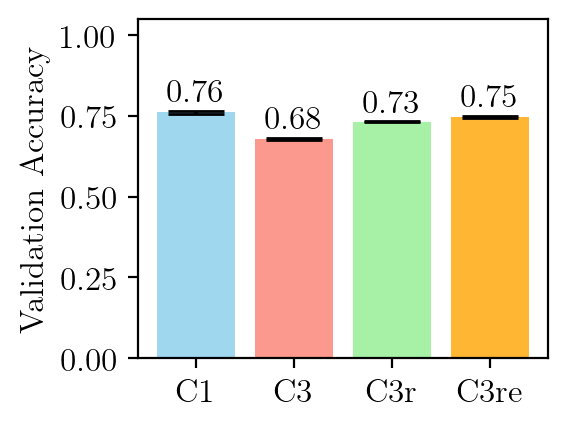

In [6]:
# r1_acc = []
# for i in range(5):
#     path = f"models/catboost_model_r1_fold{i}.cbm"
#     model = CatBoostRegressor()
#     model.load_model(path)
#     y_pred = np.abs(np.round(model.predict(X_arr)))
#     acc = accuracy_score(
#         utils_ml.reconvert_labels(y_pred, class_to_poles),
#         utils_ml.reconvert_labels(y_arr_regression, class_to_poles)
#     )
#     r1_acc.append(acc)

c1_acc = []
for i in range(5):
    path = f"models/catboost_model_c1_fold{i}.cbm"
    model = CatBoostClassifier()
    model.load_model(path)
    y_pred = model.predict(X_arr).flatten()
    acc = accuracy_score(y_pred,y_arr_classification.flatten())
    c1_acc.append(acc)

# r3_acc = []
# for i in range(5):
    
#     path_bb = f"models/catboost_model_r3_bb_fold{i}.cbm"
#     path_bt = f"models/catboost_model_r3_bt_fold{i}.cbm"
#     path_tb = f"models/catboost_model_r3_tb_fold{i}.cbm"

#     model_bb = CatBoostRegressor()
#     model_bt = CatBoostRegressor()
#     model_tb = CatBoostRegressor()

#     model_bb.load_model(path_bb)
#     model_bt.load_model(path_bt)
#     model_tb.load_model(path_tb)

#     y_pred_bb = np.abs(np.round(model_bb.predict(X_arr)))
#     y_pred_bt = np.abs(np.round(model_bt.predict(X_arr)))
#     y_pred_tb = np.abs(np.round(model_tb.predict(X_arr)))

#     y_pred = np.stack([y_pred_bt, y_pred_bb, y_pred_tb],axis=1)
    
#     acc = accuracy_score(
#         utils_ml.reconvert_labels(y_pred, class_to_poles),
#         utils_ml.reconvert_labels(y_arr_regression, class_to_poles)
#     )
#     r3_acc.append(acc)

c3_acc = []
for i in range(5):
    
    path_bb = f"models/catboost_model_c3_bb_fold{i}.cbm"
    path_bt = f"models/catboost_model_c3_bt_fold{i}.cbm"
    path_tb = f"models/catboost_model_c3_tb_fold{i}.cbm"

    model_bb = CatBoostClassifier()
    model_bt = CatBoostClassifier()
    model_tb = CatBoostClassifier()

    model_bb.load_model(path_bb)
    model_bt.load_model(path_bt)
    model_tb.load_model(path_tb)

    y_pred_bb = model_bb.predict(X_arr).flatten()
    y_pred_bt = model_bt.predict(X_arr).flatten()
    y_pred_tb = model_tb.predict(X_arr).flatten()

    y_pred = np.stack([y_pred_bt, y_pred_bb, y_pred_tb],axis=1)
    
    acc = accuracy_score(
        utils_ml.reconvert_labels(y_pred, class_to_poles),
        y_arr_classification
    )
    c3_acc.append(acc)


c3r_acc = []
for i in range(5):

    base_clf = WrappedCatBoost(loss_function='MultiClass', random_seed=42)

    new_chain = ClassifierChain(base_estimator=base_clf, order=[0, 1, 2])
    new_chain.load_chain(f"models/catboost_model_c3r_fold{i}",classes=np.unique(y_arr_regression))

    # Verify loaded model works
    y_pred = new_chain.predict(X_arr)
    acc = accuracy_score(utils_ml.reconvert_labels(y_pred,class_to_poles),utils_ml.reconvert_labels(y_arr_regression,class_to_poles))
    c3r_acc.append(acc)

c3ru_acc = []
for i in range(5):

    base_model = EnsembleWrapper(esize=5, iterations=1000, seed=42)

    unique_classes = np.array([0, 1, 2,])
    new_chain = EvalClassifierChain(base_estimator=base_model, order=[0, 1, 2])
    new_chain.load_chain(f"models/catboost_model_c3ru_fold{i}", classes=np.unique(y_arr_regression))
    
    # Verify loaded model works
    y_pred = new_chain.predict(X_arr)
    acc = accuracy_score(utils_ml.reconvert_labels(y_pred,class_to_poles),utils_ml.reconvert_labels(y_arr_regression,class_to_poles))
    c3ru_acc.append(acc)


means = [np.mean(c1_acc), np.mean(c3_acc), np.mean(c3r_acc), np.mean(c3ru_acc)]
stds  = [np.std(c1_acc), np.std(c3_acc), np.std(c3r_acc), np.std(c3ru_acc)]

# Bar labels
labels = ['C1', 'C3', 'C3r', 'C3re']
x_pos = np.arange(len(labels))

# Plot
# plt.figure(figsize=(4, 3)) #3, 2.3
plt.figure(figsize=(3, 2.3))
plt.bar(x_pos, means, yerr=stds, align='center', alpha=0.8, capsize=10, color=['skyblue', 'salmon', 'lightgreen', 'orange'])
plt.xticks(x_pos, labels)
plt.ylabel('Validation Accuracy')
# plt.title('Model Accuracy with Error Bars (5-Fold)')
plt.ylim(0, 1.05)

# Optionally, add the values on top of bars
for i, (mean, std) in enumerate(zip(means, stds)):
    plt.text(i, mean + std + 0.01, f'{mean:.2f}', ha='center', va='bottom')

plt.tight_layout()
plt.savefig("clf_performance.pdf", dpi=300, bbox_inches='tight', pad_inches=0)
plt.show()